In [ ]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import copy
import time
import scipy.sparse as sp

In [ ]:
# Imports for Baysian Hyperparameter tuning
try:
    from skopt import gp_minimize
    from skopt.space import Real
except ModuleNotFoundError:
    ! pip install --quiet scikit-optimize
    from skopt import gp_minimize
    from skopt.space import Real
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.3 MB/s eta 0:00:00


In [ ]:
# Define the objective function you want to optimize
# This is here as a test
#def objective(x):
#    #print(x)
#    x=np.array(x)
#    #print(x)
#    #print(np.shape(x))
#    noise = np.random.normal(loc=0, scale=0.1)  # Add Gaussian noise
#    return np.sum((x + noise-1) ** 2)

In [ ]:
# The variable "dimensions" defines the search space and the parameters. Define a list where every element corresponds to one parameter (one parameter one dimension). Every dimension
# has a defined range for the search space and a prior for the initial sampling of the n_random_starts points.
# In the example below, our paramter space is $R^2$ and the range is -3 to 3 for every dimension. We sample from a uniform grid
#on -3 to 4 for every dimension when picking the n_random_starts initial number of points.

#dimensions = [Real(-3, 3, name='x{}'.format(i),prior='uniform') for i in range(2)]

#print(dimensions)

# Perform Bayesian optimization. Objective would be the cost function we are minimizing ion our case.
#result = gp_minimize(objective, dimensions,n_calls=100,n_random_starts=5)

# Print the optimal parameters and objective value
#print('Optimal parameters: {}'.format(result.x))
#print('Optimal objective value: {}'.format(result.fun))

In [ ]:
#plt.plot(np.log(result.x_iters),'o')

In [ ]:
# Lorenz 96 system of dimension d = X.shape[0]
# todo: implement in tensorflow can be done with convolutions
def Lorenz_96(X,F=8):
  X1 = np.take(X,range(1,X.shape[0]+1),mode='wrap',axis=0)
  Xm2 = np.take(X,range(-2,X.shape[0]-2),mode='wrap',axis=0)
  Xm1 = np.take(X,range(-1,X.shape[0]-1),mode='wrap',axis=0)
  return (X1-Xm2)*Xm1-X+F

In [ ]:
# Just used to initialize my functions for now
ts = np.linspace(0,2,1000)
h = ts[1] - ts[0]

In [ ]:
# Runga Kutta integrater,
#
# z0s - initial data
# f   - function defining the ODE
#
#
def RK4IntegrateVec(z0s,f=Lorenz_96,numsteps=int(len(ts)/1),h=h):
  answ = z0s;
  sol = np.zeros((z0s.shape[0],numsteps,z0s.shape[1]));
  sol[:,0,:] = answ
  for i in range(1,numsteps):
    k1 = f(answ)
    k2 = f(answ+h*.5*k1)
    k3 = f(answ+h*.5*k2)
    k4 = f(answ+h*k3)
    temp = answ + h*(1/6.*k1 + 1/3.*k2 + 1/3.*k3 + 1/6.*k4)
    sol[:,i,:] = np.reshape(temp,(temp.shape[0],temp.shape[1]))
    answ = temp
  return sol

In [ ]:
ts = np.linspace(0,20,1001)
zIns = np.random.randn(100*1024).reshape(1024,100)
startTime = time.time()
trajs = RK4IntegrateVec(zIns,f=Lorenz_96,numsteps=len(ts),h=(ts[1]-ts[0]))
print(time.time()-startTime)

2.306069850921631


In [ ]:
trajsTest = trajs[:,:,50:]
trajs = trajs[:,:,:50]

In [ ]:
trajs.shape

(1024, 1001, 50)

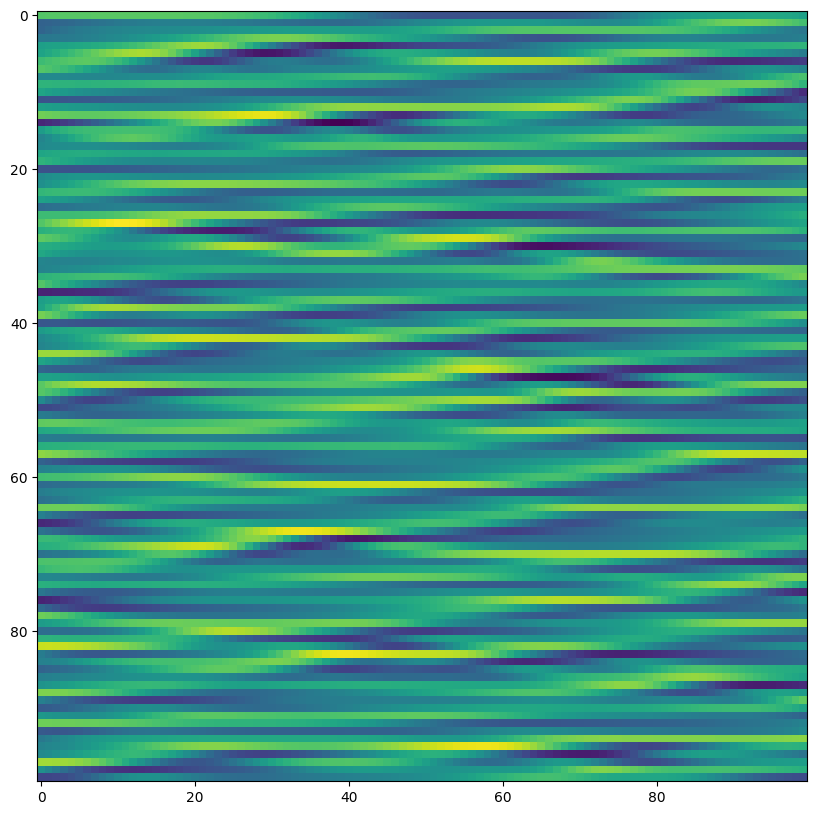

In [ ]:
plt.figure(figsize=(15,10))
plt.imshow(trajs[:100,500:600,0])

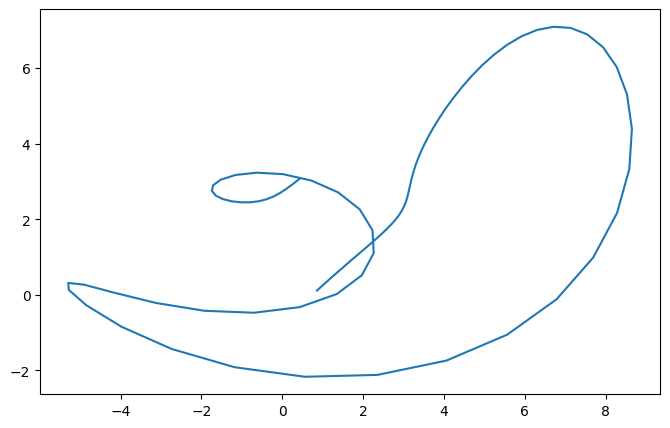

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(trajs[0,:,0],trajs[1,:,0])

In [ ]:
kernSig = 10**(-.1)
def gaussianK(X,Y,sigma=kernSig):
  X2 = np.sum(X*X,axis=0)
  Y2 = np.sum(Y*Y,axis=0)
  XY = np.dot(X.T,Y)
  # -X2 - Y2 + 2XY = ||X-Y||^2
  # f(||X-Y||), f(np.sqrt(-X2 - Y2 + 2XY))
  return np.exp((-X2[:,None]-Y2[None,:]+2*XY)/(2*sigma**2))

def polynomial(X,Y,sigma=1,order=2):
  return ((X).T@(Y) + sigma)**order

def min_sum_kernel(X,Y,sigma=1):
  minimum = np.minimum(X[:,:,None],Y[:,None,:])
  return np.sum(minimum,axis=0)

gaussianK = min_sum_kernel

In [ ]:
# prompt: entrywise min across an axis with numpy and an example

import numpy as np

def entrywise_min(X, Y, axis=0):
  """
  Computes the entrywise minimum of two arrays along a specified axis.

  Args:
    X: The first NumPy array.
    Y: The second NumPy array.
    axis: The axis along which to compute the minimum. Defaults to 0.

  Returns:
    A NumPy array representing the entrywise minimum.
  """

  return np.minimum(X, Y)


# Example
X = np.array([[1, 2, 3], [4, 5, 6]])
Y = np.array([[7, 8, 9], [10, 11, 12]])

# Entrywise minimum along axis 0
result = entrywise_min(X, Y, axis=0)
print("Entrywise minimum along axis 0:\n", result)

# Entrywise minimum along axis 1 (you would need arrays with compatible shapes for this)
# result_axis_1 = np.minimum(X, Y, axis =1) # this would produce an error


Entrywise minimum along axis 0:
 [[1 2 3]
 [4 5 6]]


In [ ]:
# We will be using Scaled and Shifted Legendre Polynomials
# ts - The array of times to evaluate the legendre polynomials at
# n  - the order of the polynomial (integer with 0 <= n).
# a  - The left end of the interval to shift the polynomials to
# b  - the right end of the interval to shift the polynomials to. (b > a)
# Computes the Legendre Polynomials based on the recursion:
# P_{n+1}(x) = [(2n+1)xP_{n}(x) - n*P_{n-1}(x)]/(n+1)
def phis(ts,n,a,b):
  # Apply the transformation of ts to tsp (on the interval [-1,1])
  if n == 0:
    Ts = np.ones((len(ts),1))
    return Ts
  tsp = (2/(b-a))*ts - (b+a)/(b-a)
  Ts = np.ones((len(ts),n+1))
  Ts[:,1] = tsp
  for i in range(2,n+1):
    Ts[:,i] = ((2*(i-1)+1)*tsp*Ts[:,i-1] - (i-1)*Ts[:,i-2])/(i)
  # The normalization term for the scaled Legendre Polynomial is
  # sqrt((2*n+1)/2)*sqrt(2/(b-a))
  Ts = Ts*np.sqrt((np.array(range(n+1))*2+1)/2)[None,:]*np.sqrt(2/(b-a))
  return Ts

# We will be using Scaled and Shifted Legendre Polynomials
# We need the derivatives as well.
# ts - The array of times to evaluate the legendre polynomials at
# n  - the order of the polynomial (integer with 0 <= n).
# a  - The left end of the interval to shift the polynomials to
# b  - the right end of the interval to shift the polynomials to. (b > a)
# Computes the derivative of the Legendre Polynomials based on the recursion:
# P_{n+1}(x) = [(2n+1)xP_{n}(x) - n*P_{n-1}(x)]/(n+1), which implies:
# P'_{n+1}(x) = [(2n+1)P_{n}(x) + (2n+1)xP'_{n}(x)-n*P'_{n-1}(x)]/(n+1)
def phisp(ts,n,a,b):
  # Apply the transformation of ts to tsp (on the interval [-1,1])
  tsp = (2/(b-a))*ts - (b+a)/(b-a)
  if n == 0:
    return np.ones((len(ts),1)), np.zeros((len(ts),1))
  Ts = np.ones((len(ts),n+1))
  Tsp = np.zeros((len(ts),n+1))
  Ts[:,1] = tsp
  Tsp[:,1] = 1
  for i in range(2,n+1):
    Ts[:,i] = ((2*(i-1)+1)*tsp*Ts[:,i-1] - (i-1)*Ts[:,i-2])/(i)
    Tsp[:,i] = ((2*(i-1)+1)*Ts[:,i-1]+(2*(i-1)+1)*tsp*Tsp[:,i-1] - (i-1)*Tsp[:,i-2])/(i)
  # The normalization term for the scaled Legendre Polynomial is
  # sqrt((2*n+1)/2)*sqrt(2/(b-a))
  Ts = Ts*np.sqrt((np.array(range(n+1))*2+1)/2)[None,:]*np.sqrt(2/(b-a))
  Tsp = Tsp*np.sqrt((np.array(range(n+1))*2+1)/2)[None,:]*np.sqrt(2/(b-a))*(2/(b-a))
  return Ts,Tsp

In [ ]:
# Requires a list of ts a list of qs, and outputs a block diagonal matrix
# cooresponding to the QPhi block diagonal matrix. Probably the least
# efficient part of the code. (loops through the trajectories)
def Calculate_QPhi(qs,ts,n):
  psArr = []
  pspArr = []
  for i in range(len(ts)):
    ps, psp = phisp(ts[i],n,ts[i][0],ts[i][-1])
    psp = -(psp[:]*qs[i][:,None])
    # Add boundary terms to psp
    psp[0,:] = psp[0,:]-ps[0,:]
    psp[-1,:] = psp[-1,:]+ps[-1,:]
    psp = psp.T
    ps = (ps*qs[i][:,None]).T
    psArr.append(ps)
    pspArr.append(psp)
  return sp.block_diag(psArr), sp.block_diag(pspArr)

# QPhi is the block diagonal matrix computed by the Calculate_QPhi function
def Calculate_M(QPhi,dataX,dataY,kernel=lambda X, Y : gaussianK(X,Y,sigma=kernSig)):
  G = kernel(dataX,dataY)
  return QPhi@(G@(QPhi.T))

# Calculate f, requires Qhi, alpha, and the data to evaluate f at (dataX) as
# well as the data of the training set (dataY). (alpha should be matrix valued)
def Calculate_f(QPhi,dataX,dataY,alpha,kernel = gaussianK, sigma= kernSig):#kernel = lambda X, Y : gaussianK(X,Y, sigma=kernSig)):
  G = kernel(dataX,dataY,sigma)
  #print(G.shape)
  #print(QPhi.shape)
  return alpha.T@((G@(QPhi.T)).T)

# Calculate Y, requires QPhi, DPhiD (derivatives of QPhi), data, and qs (to recover
# Phi from QPhi)
def Calculate_y(QPhiD,qs,dataX):
  print("Ys calc")
  ys = dataX@(QPhiD.T)
  print(np.linalg.norm(ys))
  return ys

def learn_alpha(dataset,ts,qs,n,lambdaReg=.0000001,sigma=kernSig,kern = gaussianK):
  startTime =time.time()
  print("Sigmas:")
  print(sigma)
  Qphi, QphiD = Calculate_QPhi(qs,ts,n)
  print("Time to create Phis:")
  print(time.time()-startTime)
  startTime = time.time()
  M = Calculate_M(Qphi,dataset,dataset,kernel= lambda X, Y : kern(X,Y, sigma=sigma))
  print("Time to create Double Integral Matrix:")
  print(time.time() - startTime)
  startTime = time.time()
  ys = Calculate_y(QphiD,qs,dataset)
  print("Time to calculate ys:")
  print(time.time()-startTime)
  startTime = time.time()
  alphas = np.linalg.solve(M+lambdaReg*np.eye(M.shape[0]),ys.T)
  print(np.linalg.norm(alphas))
  print("Time to solve system:")
  print(time.time()-startTime)
  return alphas, Qphi

# Integrate f from new initial conditions
def integrate_f(QPhi,zs,dataY,alpha,numSteps,h,kernel=gaussianK,sigma=kernSig):
  #trajs = np.zeros(zs.shape()+(numSteps+1,))
  #print("Sigma:")
  #print(sigma)
  trajs = RK4IntegrateVec(zs,f = lambda x : Calculate_f(QPhi,x,dataY,alpha,sigma=sigma,kernel=kernel),h=h,numsteps=numSteps)
  return trajs

# Use actual derivative values on a validation set to evaluate the
# performance of a method without integrating trajectories.
def validate_with_ders(QPhi,zs,dataY,alpha,ders,kernel=gaussianK,sigma=kernSig):
  return np.linalg.norm(Calculate_f(QPhi,zs,dataY,alpha,kernel,sigma) - ders)/np.linalg.norm(ders)

def validate_with_integration(Qphi,zs,dataY,alpha,valData,numSteps,h,kernel=gaussianK,sigma=kernSig):
  startTime = time.time()
  trajs = integrate_f(Qphi,zs,dataY,alpha,numSteps,h,sigma=sigma, kernel=kernel)
  print("Integration Time: "+str(time.time()-startTime))
  return trajs

# Train (from CSV)
def train(dataFile,lambdaReg,kernSig,numTestFeats,features,trainDel='Train',testDel='Test',valDel='Validate',timeDel='t',idDel='id',quad=np.array([1/2.,1/2.]),kernel=gaussianK):
  startTime = time.time()
  n = numTestFeats - 1
  data = pd.read_csv(dataFile)
  dataTrain = data[data[trainDel]==1]
  dataTest = data[data[testDel]==1]
  dataVal = data[data[valDel]==1]
  print("Time to load data:")
  print(time.time()-startTime)
  # We will not do any cleaning of the data, but will prepare it for the algorithm
  # as follows: Get ts vectors. Very shorthand notation for for loops. (I tend to avoid this
  # for readability)
  startTime = time.time()
  # breaks up the data into trajectories by ids
  ts = [np.array(dataTrain[timeDel].loc[dataTrain[idDel]==i]) for i in dataTrain[idDel].unique()]
  print("Time to create ts")
  print(time.time()-startTime)
  # Will concatenate (which could be computationally inneficient but shouldnt be a bottleneck)
  startTime = time.time()
  qs = []
  # Create qs array
  for i in range(len(ts)):
    if len(quad) > len(ts[i]):
      print("Error, this quadrature requires at least "+str(len(quad))+" samples per trajectory")
      print("A trajectory with fewer samples was found")
      return
    else:
      try:
        # Also very inneficient but should turn any choice of quadrature to a composite rule for all trajectories
        q = np.zeros(len(ts[i]))
        q[:len(quad)] = quad*(ts[i][1]-ts[i][0])
        index = len(quad)-1
        while index < len(ts[i])-1:
          q[index:index+len(quad)] += quad*(ts[i][index+1]-ts[i][index])
          index += len(quad)-1
        qs.append(q)
      except:
        print("Error, a trajectory with inconsistent length was found")
        print("Quadratures with 3 points, require trajectories of odd length")
        print("Quadratures with 4 points, require trajectories of length 3n+1 and so on")
        return
  print("Time to create qs:")
  print(time.time()-startTime)
  trainData = dataTrain[features].to_numpy().T
  testData = dataTest[features].to_numpy().T
  valData = dataVal[features].to_numpy().T
  print(lambdaReg)
  print(kernSig)
  print(n)
  alphas, Phis = learn_alpha(trainData,ts,qs,n,lambdaReg=lambdaReg,sigma=kernSig,kern=kernel)
  print(time.time()-startTime)
  # Assumes all trajectories have the same length
  lenValTs = int(len(dataVal)/len(dataVal[idDel].unique()))
  valPreds = validate_with_integration(Phis,valData[:,::lenValTs],trainData,alphas,valData,numSteps=lenValTs,h=h,kernel=kernel,sigma= kernSig)
  loss = (np.linalg.norm(valData-valPreds.reshape((valPreds.shape[0],valPreds.shape[1]*valPreds.shape[2]),order='F'))/np.linalg.norm(valData))

  return loss, alphas, Phis, trainData, testData, valData, valPreds

In [ ]:
def save_test_to_csv(testData,squashedPredictedTrajs,features=None,storeFile='results.csv',idColumn='id'):
  # We assume squashedPredictedTrajs follows the testData
  newDF = copy.deepcopy(testData)
  #newDF = pd.Dataframe(columns=testData.columns)
  # For each id of newDF
  ids = newDF[idColumn].unique()
  print("features")
  print(features)
  print("squashed Data shape")
  print(squashedPredictedTrajs.shape)
  diffs = squashedPredictedTrajs[0,1:]-squashedPredictedTrajs[0,:-1]
  print("Diffs")
  print(diffs)
  negs = np.array(np.where(diffs <= 0))
  negs = negs.reshape(negs.shape[1])
  print(ids)
  negs = np.concatenate([[-1],negs,[squashedPredictedTrajs.shape[1]]])
  print("negs")
  print(negs)
  inc = 0
  print(len(newDF))
  print(squashedPredictedTrajs.shape)
  print(ids)
  for id in ids:
    print(id)
    #for i in range(len(features)):
    print(len(newDF[newDF[idColumn]==id]))
    print(np.shape(squashedPredictedTrajs[1:,negs[inc]+1:negs[inc+1]+1].T))
    newDF.loc[newDF[idColumn]==id,features] = squashedPredictedTrajs[1:,negs[inc]+1:negs[inc+1]+1].T
    #newDF[newDF[idColumn]==id][features[i]] = squashedPredictedTrajs[1+i,negs[inc]+1:negs[inc+1]+1]
    inc += 1
  #for id in ids:
  #  plt.figure(figsize=(8,5))
  #  plt.plot(testData[testData[idColumn]==id]['X2'])
  #  plt.plot(newDF[newDF[idColumn]==id]['X2'])
    #plt.plot(testData[testData[idColumn] == id]['X2'].to_numpy()-newDF[newDF[idColumn]==id]['X2'].to_numpy())
  newDF.to_csv(storeFile)
  return newDF

In [ ]:
theFile = 'FHN_data_1.csv'
numTestFeats = 3
dataset = pd.read_csv(theFile)
print(dataset)
h = dataset['t'][1] - dataset['t'][0]

        id     t        X1        X2  Train  Validate   Test
0        1   0.0 -0.106669 -0.005250   True     False  False
1        1   0.1 -0.041229  0.099513   True     False  False
2        1   0.2  0.103933  0.070380   True     False  False
3        1   0.3  0.140637  0.048217   True     False  False
4        1   0.4  0.132726  0.133506   True     False  False
...    ...   ...       ...       ...    ...       ...    ...
30145  150  19.6  0.196011  1.148773  False     False   True
30146  150  19.7  0.187820  1.150855  False     False   True
30147  150  19.8  0.179423  1.152810  False     False   True
30148  150  19.9  0.170806  1.154638  False     False   True
30149  150  20.0  0.161953  1.156336  False     False   True

[30150 rows x 7 columns]


In [ ]:
features = dataset.columns[2:-3]
features

Index(['X1', 'X2'], dtype='object')

In [ ]:
# The following code wraps the training and validation function above
# into a function that can be used with the baysian hyperparameter tuning
# optimization.
def optimize(x, datafile=None,features=features,n=5,timeColumn='time',idColumn='id',trainCol='Train',testCol='Test',validateCol='Validate',kernel=gaussianK):
  x = np.array(x)
  sigmas = 10.**(np.array(x[0]))
  lambdas = 10.**(np.array(x[1]))
  print(datafile)
  print(lambdas)
  print(sigmas)
  print(n)
  print(features)
  print(trainCol)
  print(testCol)
  print(validateCol)
  print(idColumn)
  print(timeColumn)
  print(kernel)
  loss, alphas, Phis, trainData, testData, valData, valPreds = train(datafile,lambdas,sigmas,n,features=features,trainDel=trainCol,testDel=testCol,timeDel=timeColumn,kernel=gaussianK)
  #loss, alphas, Phis, trainData, testData, valData, valPreds= train(datafile,lambdaReg=lambdas,kernSig=sigmas,numTestFeats=n,features=features,trainDel=trainCol,testDel=testCol,idDel=idColumn,timeDel=timeColumn,kernel=kernel)
  print("********************************************************")
  print("Current sigma:")
  print(sigmas)
  print("Current lambdas:")
  print(lambdas)
  print("Current Loss:")
  print(loss)
  print("Alphas Shape")
  print(alphas.shape)
  print("********************************************************")
  if np.isnan(loss):
    loss = 100000
  return loss

In [ ]:
dimensions = [Real(-4, 3, name='sigma',prior='uniform'),Real(-5,10, name='lambdas',prior='uniform')]


In [ ]:
numTestFeats = 3

In [ ]:
print(features)
result = gp_minimize(lambda x : optimize(x,datafile=theFile,features=features,trainCol='Train',validateCol='Validation',testCol='Test',timeColumn='t',n=numTestFeats,idColumn='id'),dimensions,n_calls=200,n_random_starts=10)
#result = gp_minimize(lambda x : optimize(x,datafile='data.csv',features=features,timeColumn='t',idColumn='id'),dimensions,n_calls=200,n_random_starts=5)

# Print the optimal parameters and objective value
print('Optimal parameters: {}'.format(result.x))
print('Optimal objective value: {}'.format(result.fun))

Streaming output truncated to the last 5000 lines.
Alphas Shape
(120, 2)
********************************************************
FHN_data_1.csv
0.20049059816760717
1000.0
3
Index(['X1', 'X2'], dtype='object')
Train
Test
Validation
id
t
<function min_sum_kernel at 0x7e4ba1793600>
Time to load data:
0.019472122192382812
Time to create ts
0.006437778472900391
Time to create qs:
0.015550374984741211
0.20049059816760717
1000.0
2
Sigmas:
1000.0
Time to create Phis:
0.0037529468536376953
Time to create Double Integral Matrix:
0.6178243160247803
Ys calc
8.446362876353762
Time to calculate ys:
0.0006892681121826172
5.977879145328647
Time to solve system:
0.0002319812774658203
0.6389403343200684
Integration Time: 0.4056999683380127
********************************************************
Current sigma:
1000.0
Current lambdas:
0.20049059816760717
Current Loss:
0.19023426715545197
Alphas Shape
(120, 2)
********************************************************
FHN_data_1.csv
0.19887647112453657
0.0

In [ ]:
result.x[0]# = np.log(1.128520193244331e-06)/np.log(10)

-3.7459192127470873

In [ ]:
result.x[1]

-0.7242372364341749

In [ ]:
#print(np.linalg.norm(valData-valPreds.reshape((valPreds.shape[0],valPreds.shape[1]*valPreds.shape[2]),order='F'))/np.linalg.norm(valData))
#valPreds.shape
#valData = valData.reshape((valData.shape[0],valPreds.shape[1],valPreds.shape[2]),order='F')

In [ ]:
#result

In [ ]:
#loss, alphas, Phis, trainData, testData, valData, valPreds = train(datafile,lambdas,sigmas,4,features=features,trainDel='Train',testDel='Test',timeDel='t',kernel=gaussianK)

loss, alphas, Phis, trainData, testData, valData, valPreds = train(theFile,10**(result.x[1]),10**(result.x[0]),numTestFeats=numTestFeats,kernel=gaussianK,features=features,trainDel='Train',testDel='Test',timeDel='t',idDel='id');
valData = valData.reshape((valData.shape[0],valPreds.shape[1],valPreds.shape[2]),order='F')
print(loss)

Time to load data:
0.020054340362548828
Time to create ts
0.008007287979125977
Time to create qs:
0.015446662902832031
0.18869603020948242
0.00017950675133817105
2
Sigmas:
0.00017950675133817105
Time to create Phis:
0.003685474395751953
Time to create Double Integral Matrix:
0.6220393180847168
Ys calc
8.446362876353762
Time to calculate ys:
0.0007188320159912109
6.282181636322052
Time to solve system:
0.0002243518829345703
0.6431002616882324
Integration Time: 0.3935716152191162
0.19011670061213465


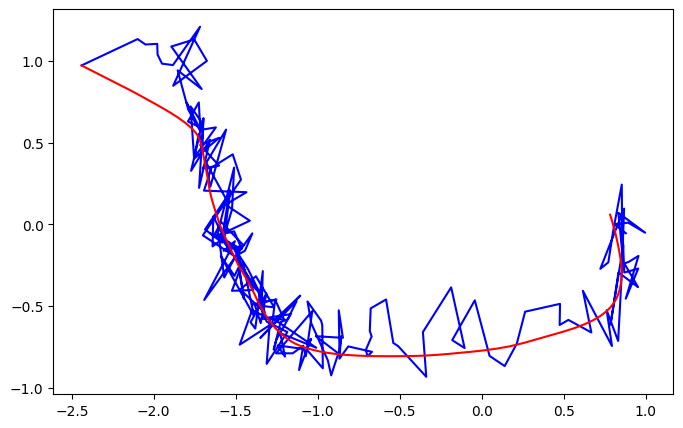

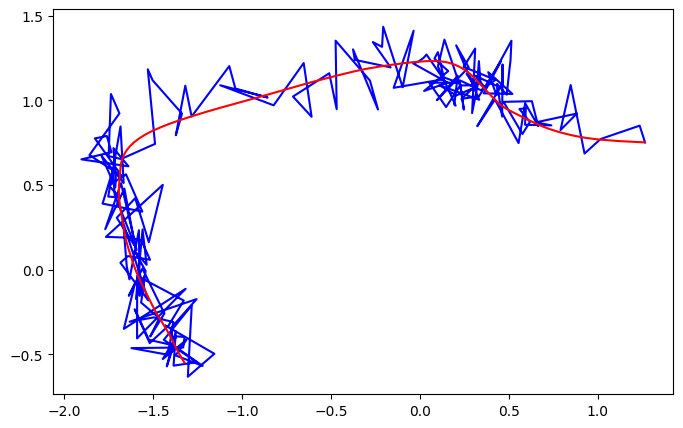

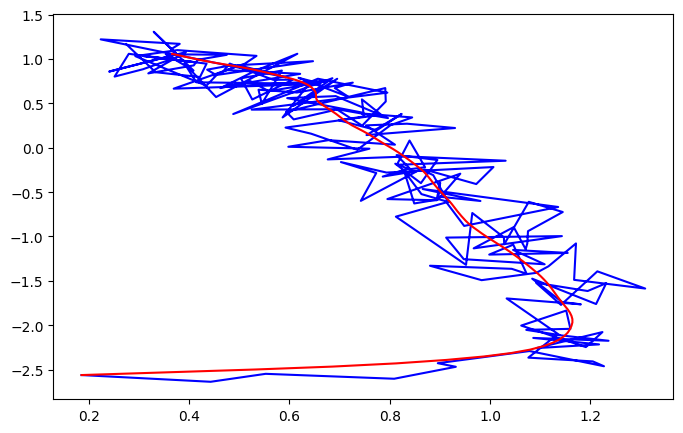

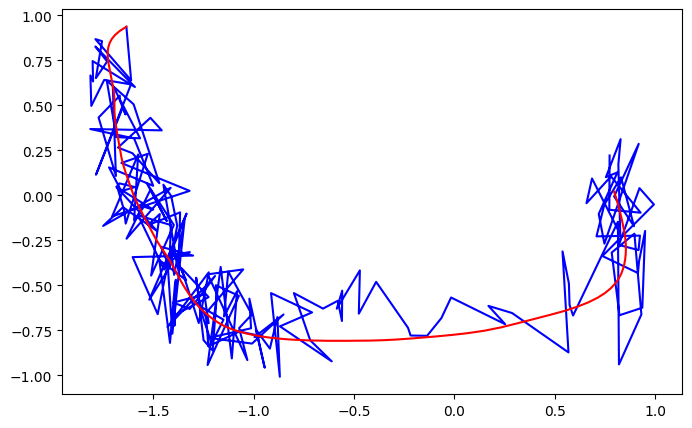

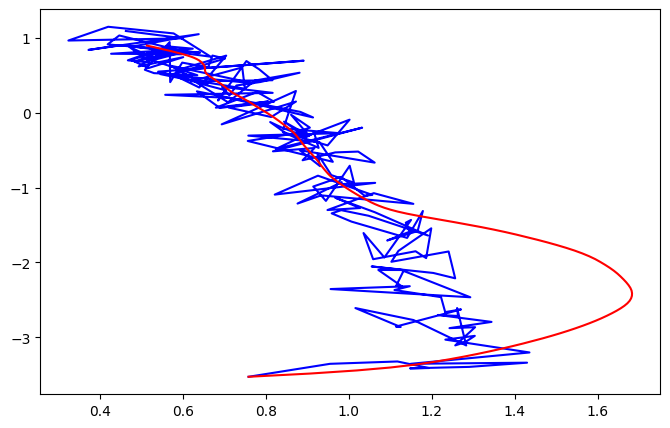

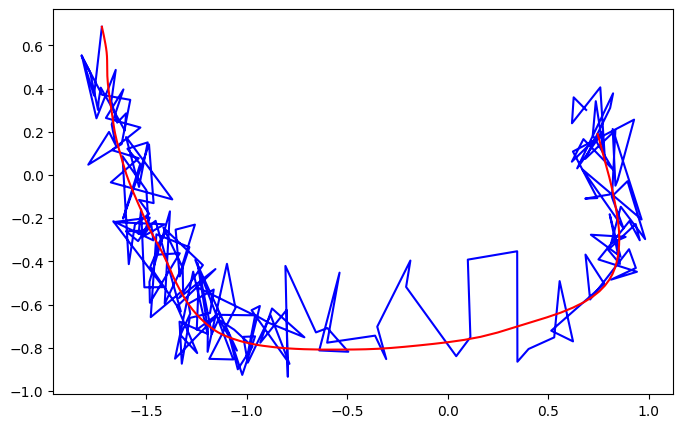

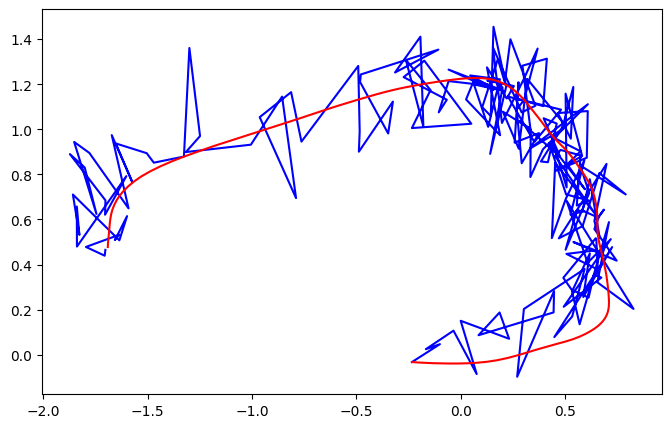

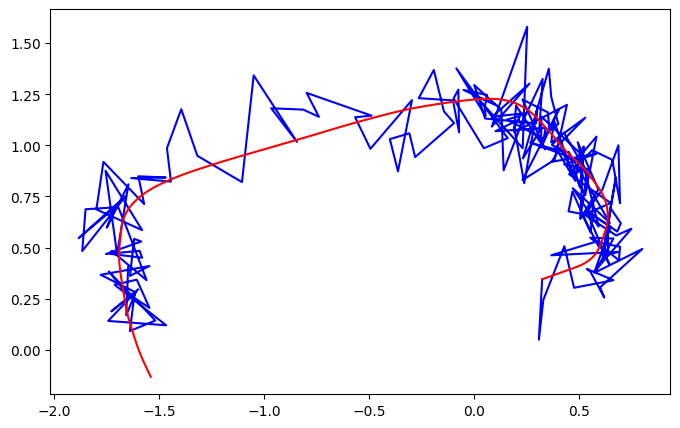

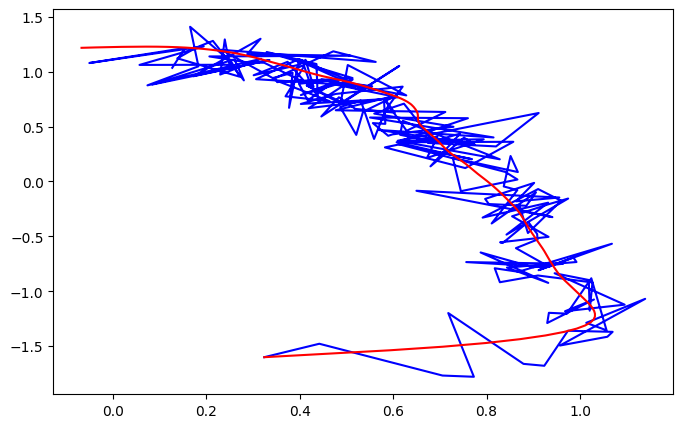

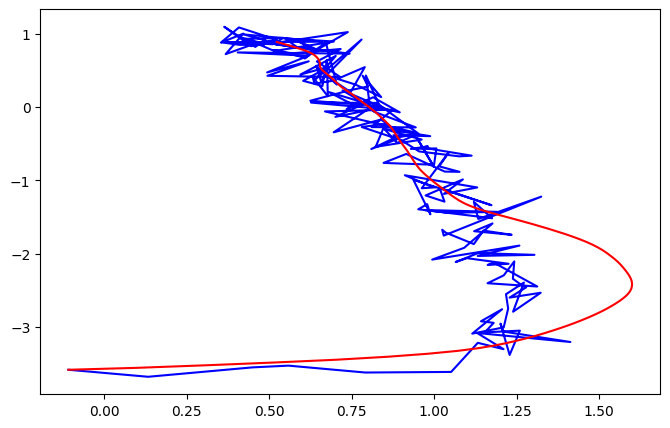

In [ ]:
for i in range(10):
  plt.figure(figsize=(8,5))
  index = i
  plt.plot(valData[0,:,index],valData[1,:,index],color='b')
  plt.plot(valPreds[0,:,index],valPreds[1,:,index],color='r')

NameError: name 'testPreds' is not defined

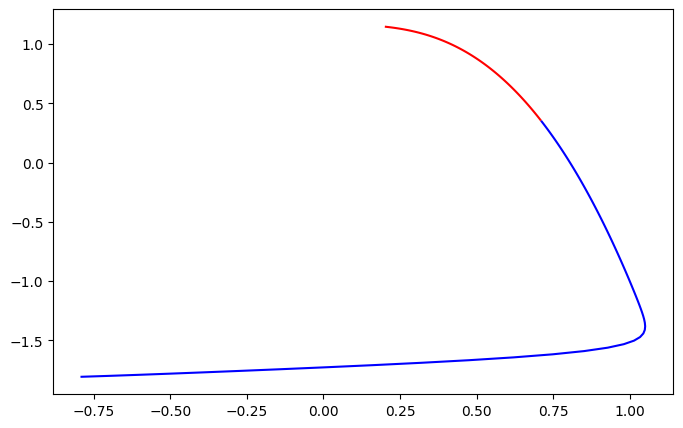

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(testData[0,:101],testData[1,:101],color='b')
plt.plot(testData[0,101:201],testData[1,101:201],color='r')


#plt.plot(testPreds[0,:,index],testPreds[1,:,index],color='r')

In [ ]:
testData.shape

(2, 7040)

In [ ]:
new_testData = np.random.rand(testData.shape[0],1000)*3
#new_testData = new_testData - (np.mean(new_testData,axis=1)[:,None])
#new_testData = new_testData/(np.std(new_testData,axis=1)[:,None])

In [ ]:
testData.shape

(2, 7040)

Integration Time: 3.887704610824585
(2, 101, 200)


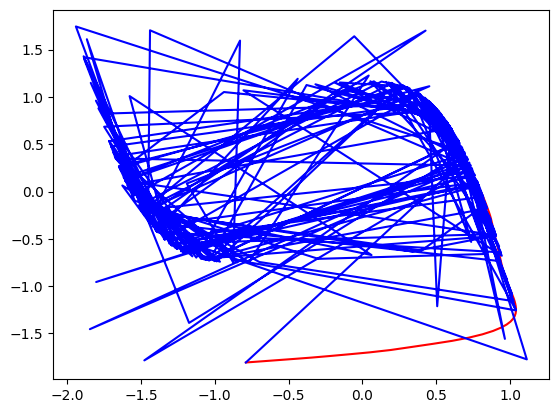

In [ ]:
#testPreds = validate_with_integration(Phis,new_testData,trainData,alphas,testData,numSteps=lenTrajs,h=h,kernel=gaussianK,sigma= 1.2002538510375889)
testPreds = validate_with_integration(Phis,testData[:,::101],trainData,alphas,testData,numSteps=101,h=h,kernel=gaussianK,sigma= 1.2002538510375889)

print(testPreds.shape)
plt.figure()
plt.plot(testPreds[0,:,0],testPreds[1,:,0],color='r')
plt.plot(testData[0,::101],testData[1,::101],color='b')

#ts = np.outer(np.linspace(0,lenTrajs*h,lenTrajs),np.ones(testPreds.shape[-1]))
#testPreds = np.concatenate((ts.reshape((1,lenTrajs,testPreds.shape[-1])),testPreds),axis=0)
#testPreds = testPreds.reshape((testPreds.shape[0],testPreds.shape[1]*testPreds.shape[2]),order='F')
#dataframe = pd.read_csv(theFile)

In [ ]:
save_test_to_csv(dataframe[dataframe['Test']==True],testPreds,features=features)